In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../outputs/serve_analysis.csv")


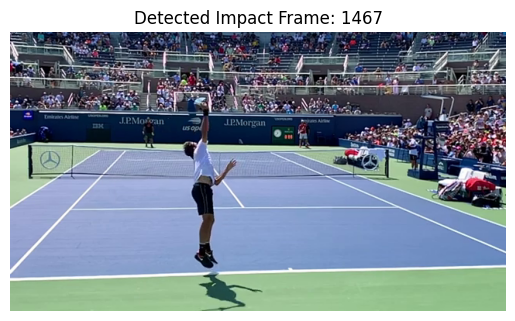

In [4]:
import cv2
import matplotlib.pyplot as plt

video_path = "../data/raw_videos/test_video.mp4"

cap = cv2.VideoCapture(video_path)

cap.set(cv2.CAP_PROP_POS_FRAMES, 1467)

ret, frame = cap.read()

plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title("Detected Impact Frame: 1467")
plt.axis("off")
plt.show()

cap.release()

In [7]:
# Ver rango real de frames
print("Min frame:", df["frame"].min())
print("Max frame:", df["frame"].max())

# Usar TODO el dataset (sin cortar)
df_small = df.copy()

# Limpiar datos
df_small = df_small.dropna(subset=["elbow_angle", "knee_angle", "wrist_height"])

# Score biomecánico
df_small["score"] = (
    df_small["elbow_angle"] +
    df_small["knee_angle"] -
    (df_small["wrist_height"] * 300)
)

# Elegir mejor frame
best_row = df_small.loc[df_small["score"].idxmax()]
impact_frame_bio = int(best_row["frame"])

print("Detected impact frame (biomechanics):", impact_frame_bio)

Min frame: nan
Max frame: nan


ValueError: attempt to get argmax of an empty sequence